In [33]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import matplotlib.lines as mlines

# === PARAMETERS ===
collections = ['lastfm', 'suno', 'udio']
base_path = "/workspace/ngram_datasets/tetragrams"
N = 20  # number of tetragrams to plot

# === LOAD DATA ===
all_ngram_data = {}
for collection in collections:
    file_path = f"{base_path}/4gram_dataset_{collection}.json"
    with open(file_path, 'r') as f:
        all_ngram_data[collection] = json.load(f)
    print(f"{collection}: {len(all_ngram_data[collection])} unique tetragrams")

# === BUILD LONG DATAFRAME: Dortmund genres, proportional ===
data_entries = []
for collection in collections:
    for ngram_entry in all_ngram_data[collection]:
        tetragram_tuple = tuple(ngram_entry["ngram"])
        count = ngram_entry["count"]
        # Proportional Dortmund genres
        total_weight = sum(w for genre, w in ngram_entry["dortmund_genres"])
        for genre, weight in ngram_entry["dortmund_genres"]:
            proportion = weight / total_weight if total_weight > 0 else 0
            genre_count = round(count * proportion)
            if genre_count > 0:
                for _ in range(genre_count):
                    data_entries.append({
                        "collection": collection,
                        "genre": genre,
                        "tetragram": tetragram_tuple,
                    })

lastfm: 578712 unique tetragrams
suno: 256945 unique tetragrams
udio: 374603 unique tetragrams


In [34]:
# === GET TOP GENRES (e.g., 12) ===
genre_counts = Counter(entry["genre"] for entry in data_entries if entry["genre"])
top_genres = [g for g, _ in genre_counts.most_common(12)]
print("Top 12 genres:", top_genres)

# === AGGREGATE TETRAGRAMS PER (GENRE, COLLECTION) ===
tetragram_counts_by_style = defaultdict(lambda: defaultdict(Counter))
for entry in data_entries:
    genre = entry["genre"]
    if genre not in top_genres:
        continue
    collection = entry["collection"]
    tetragram = entry["tetragram"]
    tetragram_counts_by_style[genre][collection][tetragram] += 1

# === BUILD LONG-FORMAT DF FOR PLOTTING ===
all_rows = []
for genre in top_genres:
    all_tetragrams = Counter()
    for collection in collections:
        all_tetragrams += tetragram_counts_by_style[genre][collection]
    topN_tetragrams = [t for t, _ in all_tetragrams.most_common(N)]
    for tetragram in topN_tetragrams:
        tetragram_str = " - ".join(tetragram)
        for collection in collections:
            count = tetragram_counts_by_style[genre][collection][tetragram]
            all_rows.append({
                "genre": genre,
                "tetragram": tetragram_str,
                "collection": collection,
                "count": count
            })
df_long = pd.DataFrame(all_rows)



Top 12 genres: ['rock', 'electronic', 'jazz', 'pop', 'country', 'hiphop', 'soul', 'blues']


In [35]:
# === NORMALIZE WITHIN GENRE & COLLECTION ===
df_long['normalized_count'] = 0
for genre in df_long['genre'].unique():
    for collection in collections:
        mask = (df_long['genre'] == genre) & (df_long['collection'] == collection)
        genre_collection_data = df_long[mask]
        if len(genre_collection_data) > 0:
            max_count = genre_collection_data['count'].max()
            if max_count > 0:
                df_long.loc[mask, 'normalized_count'] = (genre_collection_data['count'] / max_count) * 100

df_long['profile_ratio'] = df_long['normalized_count'] / 100  # 0-1 for radar

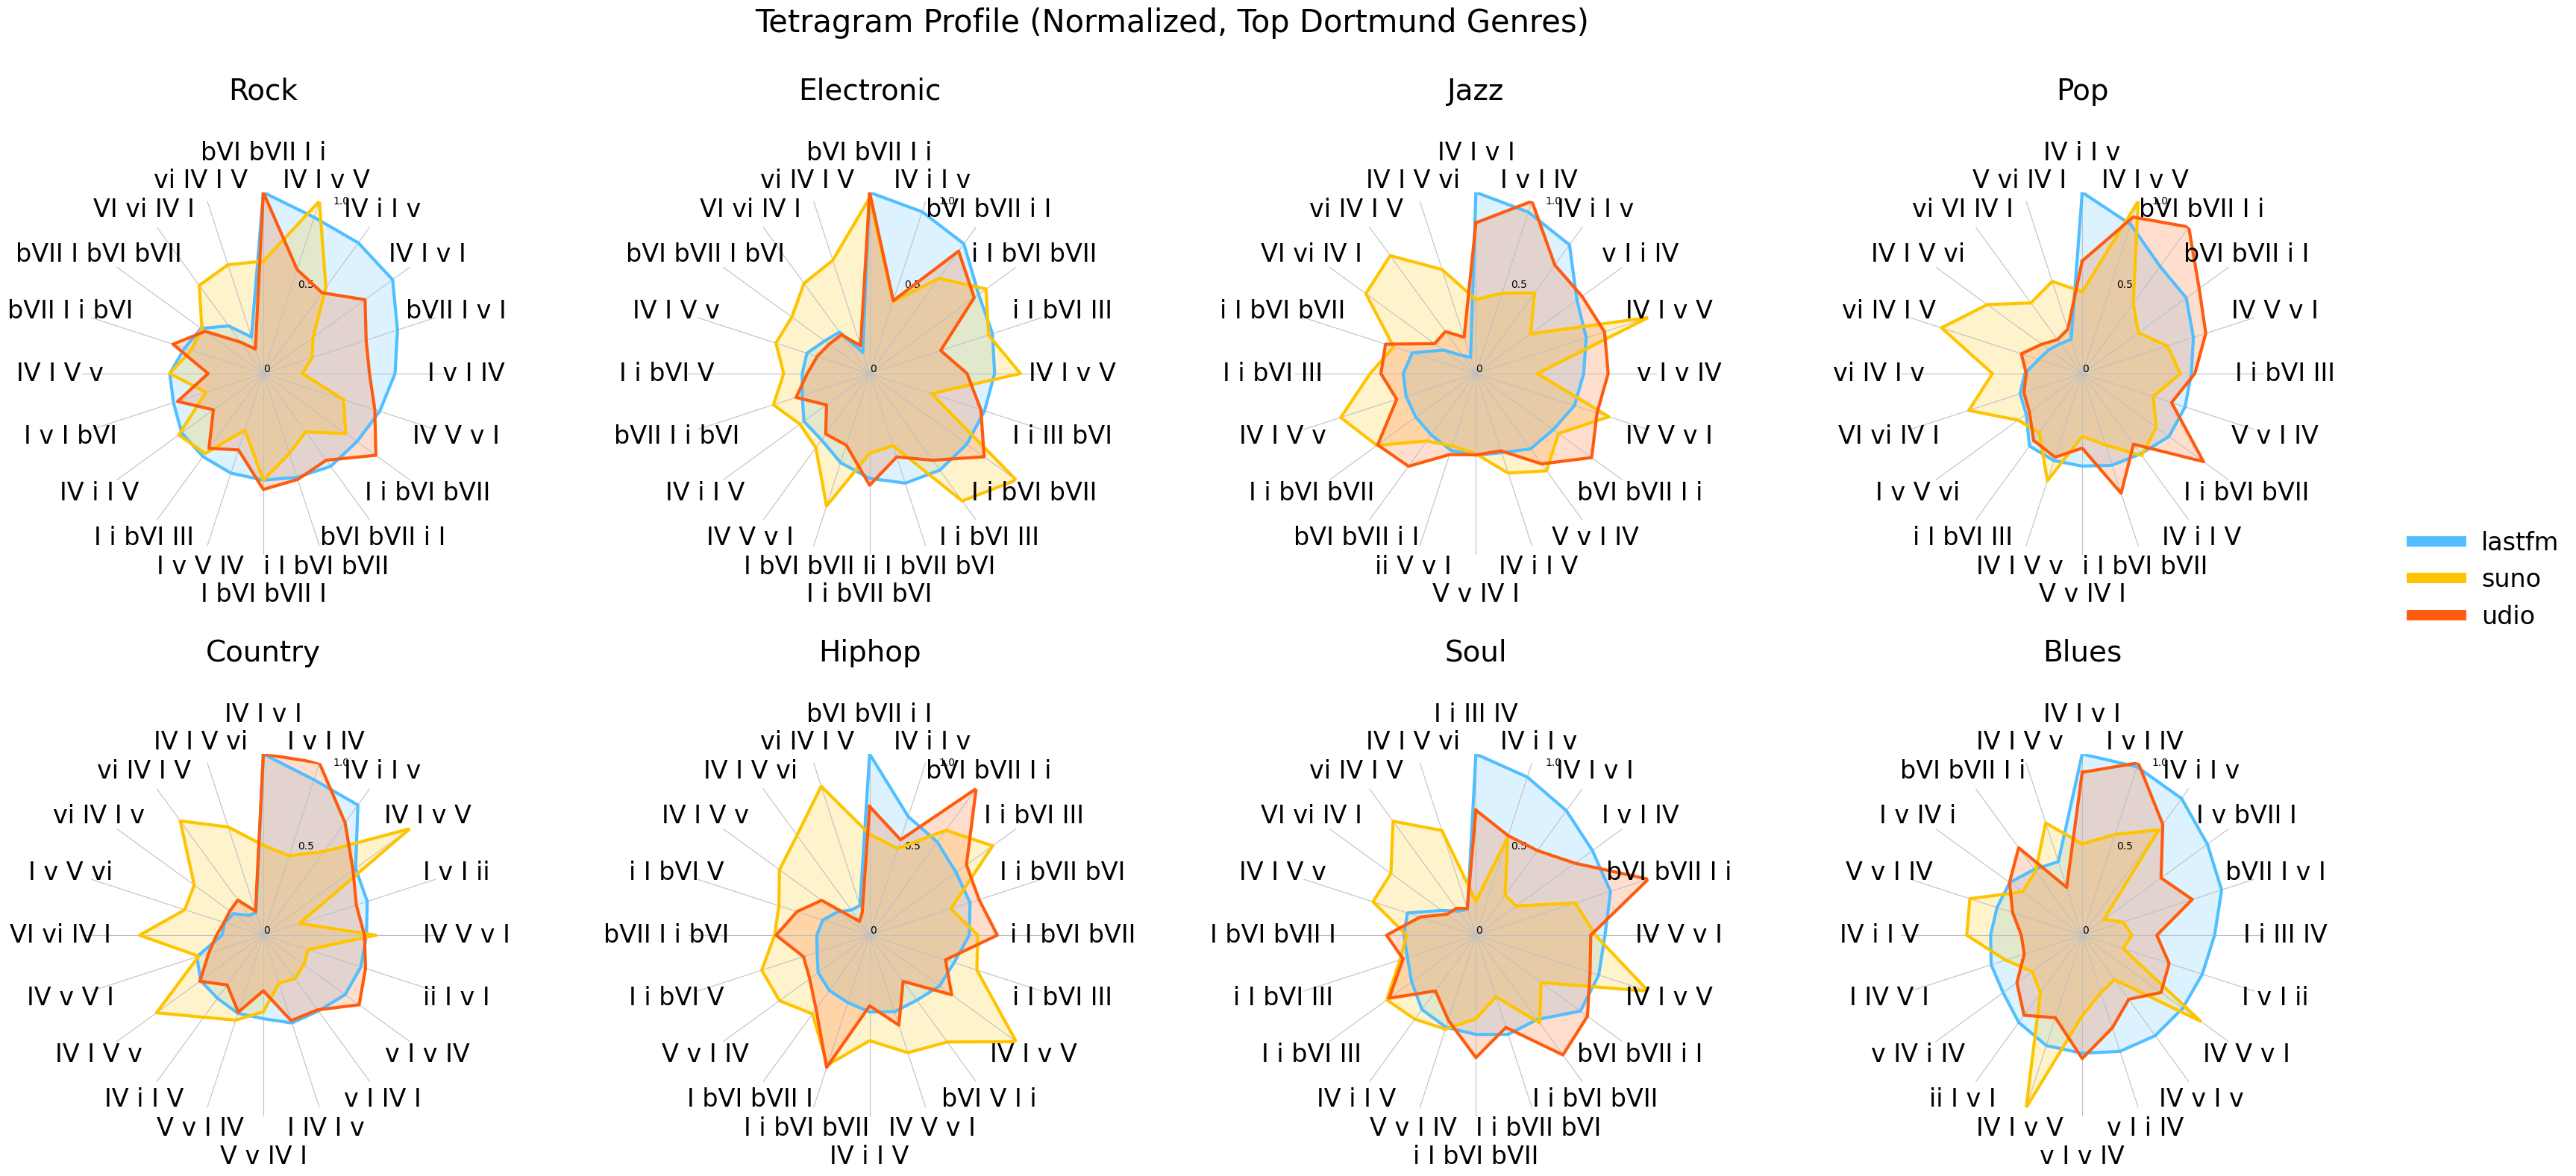

In [36]:
# === RADAR PLOT ===
colors = ["#51BFFF", "#FFC400", "#FF5B0E"]
n_genres = len(top_genres)
n_cols = 4
n_rows = int(np.ceil(n_genres / n_cols))
line_color = "#C0C0C0"

label_radius_top = 1.32      # move the top label up
label_radius_default = 1.12  # all the rest
label_radius_bottom = 0.92   # move the bottom label down

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols, figsize=(n_cols * 8, n_rows * 8),
    subplot_kw=dict(polar=True)
)
axes = axes.flatten()

# Get tetragram order per genre based on lastfm
reference_collection = "lastfm"
tetragram_order_per_genre = {
    genre: (
        df_long[
            (df_long['genre'] == genre) & (df_long['collection'] == reference_collection)
        ]
        .groupby('tetragram')['normalized_count']
        .sum()
        .sort_values(ascending=False)
        .head(N)
        .index.tolist()
    )
    for genre in top_genres
}

for ax_idx, genre in enumerate(top_genres):
    top_tetragrams = tetragram_order_per_genre[genre]
    num_vars = len(top_tetragrams)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    axes[ax_idx].set_theta_offset(np.pi / 2)
    axes[ax_idx].set_theta_direction(-1)
    for col, color in zip(collections, colors):
        subset = df_long[(df_long["genre"] == genre) & (df_long["collection"] == col)]
        subset = subset.set_index("tetragram")
        data = [subset.loc[t, "profile_ratio"] if t in subset.index else 0 for t in top_tetragrams]
        data += data[:1]
        axes[ax_idx].plot(angles, data, color=color, label=col, linewidth=3)
        axes[ax_idx].fill(angles, data, color=color, alpha=0.2)
    axes[ax_idx].set_xticks(angles[:-1])
    axes[ax_idx].set_xticklabels([])
    for i, (angle, tetragram) in enumerate(zip(angles[:-1], top_tetragrams)):
        if i == 0 or i == (num_vars // 2):
            label_radius = 1.22  # Top label: further from center
        else:
            label_radius = 1.12  # Default
        axes[ax_idx].text(
            angle, label_radius, str(tetragram).replace(' - ', ' '),
            horizontalalignment='center', verticalalignment='center',
            fontsize=24,
            transform=axes[ax_idx].transData
        )

    axes[ax_idx].set_yticks([0, 0.5, 1.0])
    axes[ax_idx].set_yticklabels(['0', '0.5', '1.0'])
    axes[ax_idx].set_ylim(0, 1)
    axes[ax_idx].spines['polar'].set_visible(False)
    axes[ax_idx].yaxis.grid(False)
    axes[ax_idx].xaxis.grid(True, color=line_color, linewidth=0.8, alpha=1.0)
    axes[ax_idx].set_title(
        f"{genre.title()}",
        fontsize=28, 
        pad=90   # MUCH MORE SPACE ABOVE PLOT
    )

for ax in axes[len(top_genres):]:
    fig.delaxes(ax)

plt.suptitle("Tetragram Profile (Normalized, Top Dortmund Genres)", fontsize=30)
plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=5.0, w_pad=3.5)
plt.subplots_adjust(hspace=0.55)   # <-- INCREASE SPACING BETWEEN ROWS, adjust as needed

line_handles = [
    mlines.Line2D([], [], color=color, linewidth=10, label=col)
    for col, color in zip(collections, colors)
]
fig.legend(
    handles=line_handles,
    labels=collections,
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
    fontsize=24,
    frameon=False
)
plt.show()

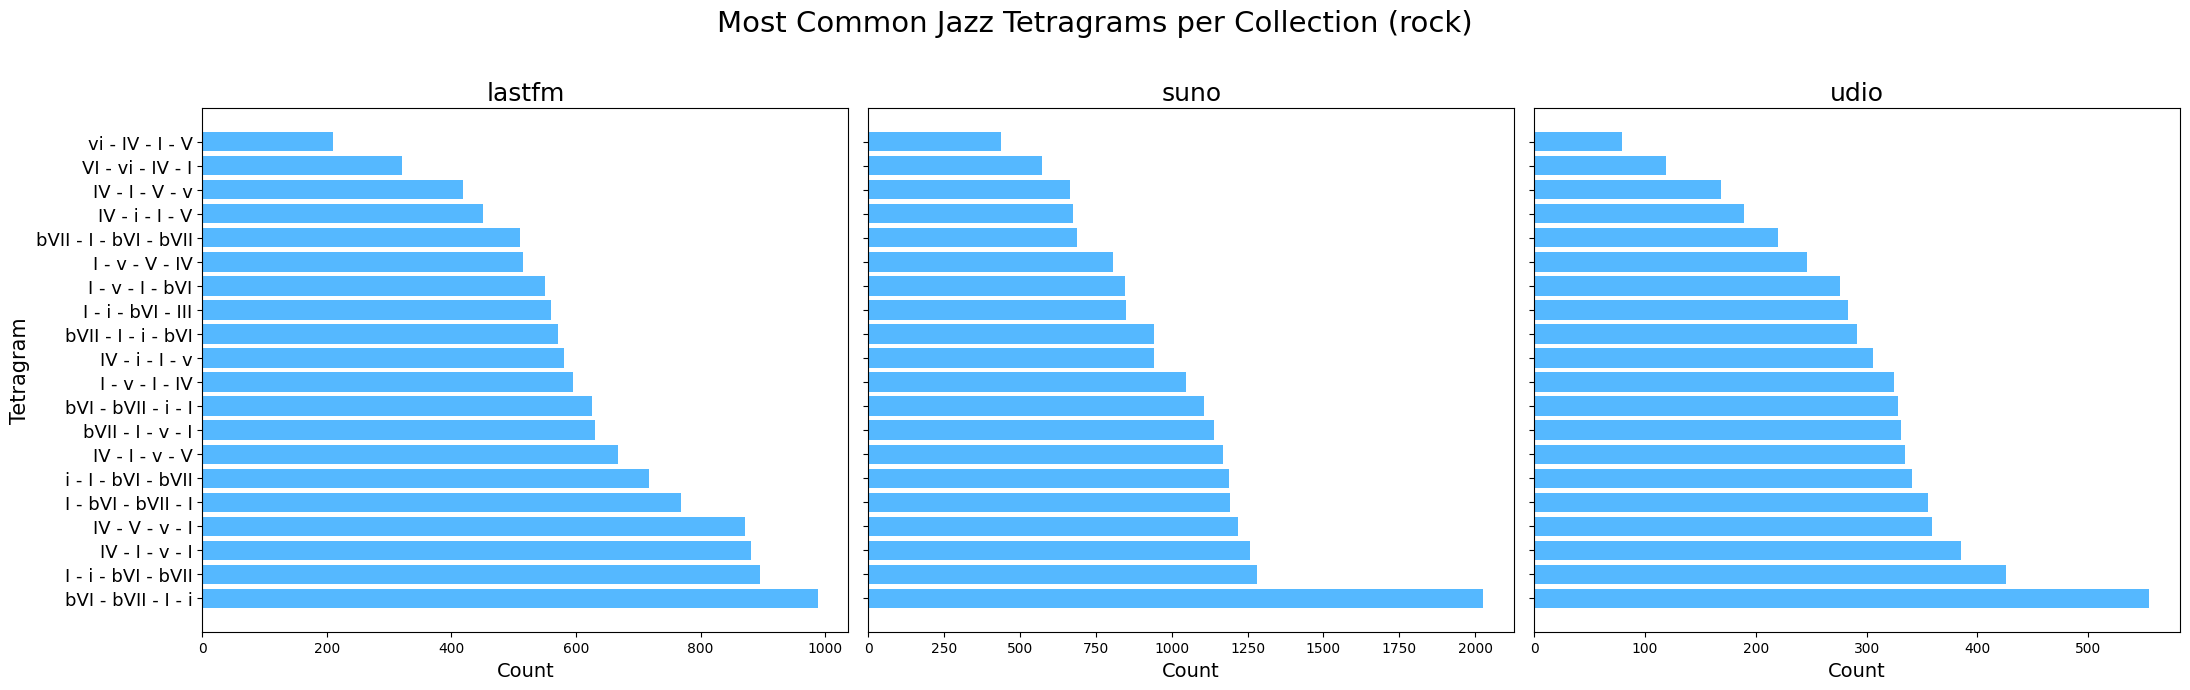

In [37]:

import matplotlib.pyplot as plt

top_n = 40
collections = ['lastfm', 'suno', 'udio']
jazz_label = 'rock'  # <-- Change if needed to match your data

fig, axes = plt.subplots(1, len(collections), figsize=(22, 7), sharey=True)

for idx, collection in enumerate(collections):
    # Filter for jazz genre and this collection
    jazz_df = df_long[(df_long['genre'] == jazz_label) & (df_long['collection'] == collection)]
    tetrad_counts = (
        jazz_df.groupby('tetragram')['count']
        .sum()
        .sort_values(ascending=False)
    )
    top_tetrads = tetrad_counts.head(top_n)
    
    axes[idx].barh(
        range(len(top_tetrads)),
        top_tetrads.values[::-1],
        color='#55b8ff'
    )
    axes[idx].set_yticks(range(len(top_tetrads)))
    axes[idx].set_yticklabels([t for t in top_tetrads.index[::-1]], fontsize=13)
    axes[idx].set_xlabel("Count", fontsize=14)
    axes[idx].set_title(collection, fontsize=18)
    axes[idx].invert_yaxis()
    
axes[0].set_ylabel("Tetragram", fontsize=15)
plt.suptitle(f"Most Common Jazz Tetragrams per Collection ({jazz_label})", fontsize=21)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
